# Introduction to Data Assimilation and the Kalman Filter

## 1. Data assimilation problem setting

Data assimilation estimates a time-evolving hidden state from an imperfect dynamical model and noisy, partial observations. The state is denoted by $v_j\in\mathbb R^d$ at discrete time $j$, while the observation is denoted by $y_j\in\mathbb R^k$. The model and observation equations are
$$
\begin{aligned}
v_{j+1}^{\dagger} &= \Psi(v_j^{\dagger}) + \xi_j^{\dagger}, \qquad
\xi_j^{\dagger}\sim \mathcal N(0,\Sigma),\\
y_{j+1}^{\dagger} &= h(v_{j+1}^{\dagger}) + \eta_{j+1}^{\dagger}, \qquad
\eta_{j+1}^{\dagger}\sim \mathcal N(0,\Gamma).
\end{aligned}
$$
Here $v_j^{\dagger}$ is the unknown true state, $\Psi$ is the forecast model, $h$ is the observation map, $\Sigma$ is the model-error covariance, and $\Gamma$ is the observation-error covariance. In practice, the observations may be low-dimensional, so $k$ can be much smaller than $d$.

The information available after the first $j$ observations is
$$
Y_j^{\dagger}=\{y_1^{\dagger},\ldots,y_j^{\dagger}\}.
$$
Data assimilation is Bayesian when it represents uncertainty about the hidden state by conditional probability distributions. The central object for filtering is the filtering distribution
$$
\pi_j = \mathbb P(v_j^{\dagger}\mid Y_j^{\dagger}).
$$
This distribution summarizes everything the observations up to time $j$ say about the current state.

### 1.1 Forecast-analysis recursion

Filtering proceeds recursively. Suppose the current filtering distribution $\pi_j$ is known. The forecast, or prediction, step pushes this distribution through the dynamics to obtain the predictive distribution
$$
\widehat\pi_{j+1} = \mathsf P\pi_j,
$$
which can be written formally as
$$
\widehat\pi_{j+1}(dv)=\int p(dv\mid u)\,\pi_j(du),
$$
where $p(dv\mid u)$ is the transition law induced by
$$
v=\Psi(u)+\xi,\qquad \xi\sim\mathcal N(0,\Sigma).
$$
After the new observation $y_{j+1}^{\dagger}$ arrives, the analysis step applies Bayes' rule:
$$
\pi_{j+1}(dv)=\mathsf A_{j+1}\widehat\pi_{j+1}(dv)
=\frac{1}{Z_{j+1}}\exp\left(-\frac12\left\|y_{j+1}^{\dagger}-h(v)\right\|_{\Gamma}^{2}\right)\widehat\pi_{j+1}(dv),
$$
where
$$
\|a\|_{\Gamma}^{2}=a^T\Gamma^{-1}a
$$
and $Z_{j+1}$ is the normalization constant that makes $\pi_{j+1}$ integrate to one.

This gives the compact filtering recursion
$$
\widehat\pi_{j+1}=\mathsf P\pi_j,
\qquad
\pi_{j+1}=\mathsf A_{j+1}\widehat\pi_{j+1}.
$$
Different filtering algorithms can be understood as different ways to approximate or exactly compute this recursion; the linear Gaussian case leads to the Kalman filter.

### 1.2 Filtering versus smoothing

The filtering problem estimates the present state using only observations available up to the present:
$$
\pi_j=\mathbb P(v_j^{\dagger}\mid Y_j^{\dagger}).
$$
The smoothing problem estimates a past state using a longer observation window:
$$
\mathbb P(v_j^{\dagger}\mid Y_J^{\dagger}),\qquad J>j.
$$
This notebook focuses only on filtering. The goal is to show how the forecast-analysis recursion becomes explicit in the linear Gaussian case, where the Kalman filter propagates means and covariances exactly.

See Chapter 6, Section 6.2: Formulation Of Data Assimilation, and Chapter 6, Section 6.3.1: Kalman Filter. 

### 1.3 Linear Gaussian experiment setting

The experiment uses a rotating two-dimensional linear Gaussian model
$$
v_{j+1}=Av_j+\xi_j,
\qquad
\xi_j\sim \mathcal N(0,\Sigma),
$$
with either full observations or first-coordinate observations
$$
y_{j+1}=Hv_{j+1}+\eta_{j+1},
\qquad
\eta_{j+1}\sim \mathcal N(0,\Gamma).
$$
The matrix $A$ is a fixed rotation, $\Sigma=\sigma_v^2I$, and $\Gamma=\sigma_y^2I$ on the observed coordinates. This setting is intentionally small enough that the forecast and analysis covariance ellipses can be inspected directly.



## 2. Kalman filter from predictive moments and affine analysis maps

We first derive the linear Kalman update using the cleanest covariance notation, then embed it into an affine analysis map.

### 2.1 Kalman update from predictive moments

At time $j+1$, let the predictive (prior) state be
$$
\widehat v_{j+1} \sim \mathcal N(\widehat m_{j+1},\widehat C_{j+1}),
$$
and define predictive observation
$$
\widehat y_{j+1} = H\widehat v_{j+1} + \eta_{j+1}, \qquad \eta_{j+1}\sim\mathcal N(0,\Gamma).
$$
So
$$
\widehat m_{j+1}^{y}=\mathbb E[\widehat y_{j+1}] = H\widehat m_{j+1},
\qquad
\widehat C_{j+1}^{vy}=\mathrm{Cov}(\widehat v_{j+1},\widehat y_{j+1}),
\qquad
\widehat C_{j+1}^{yy}=\mathrm{Cov}(\widehat y_{j+1},\widehat y_{j+1}).
$$
In the linear-Gaussian case,
$$
\widehat C_{j+1}^{vy}=\widehat C_{j+1}H^T,
\qquad
\widehat C_{j+1}^{yy}=H\widehat C_{j+1}H^T+\Gamma.
$$

Assume analysis uses the increment form
$$
v_{j+1} = \widehat v_{j+1} + K_{j+1}\big(y_{j+1}^{\dagger} - h(\widehat v_{j+1})\big).
$$
For $h(v)=Hv$,
$$
v_{j+1} = \widehat v_{j+1} + K_{j+1}\big(y_{j+1}^{\dagger} - H\widehat v_{j+1}\big).
$$
Matching Gaussian posterior moments gives
$$
m_{j+1} = \widehat m_{j+1} + K_{j+1}\big(y_{j+1}^{\dagger} - \widehat m_{j+1}^{y}\big),
$$
$$
C_{j+1} = (I-K_{j+1}H)\widehat C_{j+1}(I-K_{j+1}H)^T + K_{j+1}\Gamma K_{j+1}^T.
$$
and the Kalman gain is written directly as
$$
K_{j+1}=\widehat C_{j+1}^{vy}\,(\widehat C_{j+1}^{yy})^{-1}.
$$
In matrix form for this testbed,
$$
K_{j+1}=\widehat C_{j+1}H^T\big(H\widehat C_{j+1}H^T+\Gamma\big)^{-1}.
$$

### 2.2 Affine analysis map viewpoint

Now write a general affine analysis map
$$
v_{j+1}=\mathcal A_{j+1}(\widehat\pi_{j+1},y_{j+1}^{\dagger})\widehat v_{j+1}
+\mathcal B_{j+1}(\widehat\pi_{j+1},y_{j+1}^{\dagger})\widehat y_{j+1}
+a_{j+1}(\widehat\pi_{j+1},y_{j+1}^{\dagger}).
$$
Imposing exactness with the Kalman target moments gives
$$
a_{j+1}=(I-\mathcal A_{j+1})\,\widehat m_{j+1}
+K_{j+1}y_{j+1}^{\dagger}
-(\mathcal B_{j+1}+K_{j+1})\,\widehat m_{j+1}^{y}.
$$
For Kalman filter,
$$
\mathcal A_{j+1}=I,\ \mathcal B_{j+1}=-K_{j+1}\quad\Rightarrow\quad\text{Kalman filter},
$$
and other Gaussian filters can be interpreted as alternative choices of $(\mathcal A_{j+1},\mathcal B_{j+1})$ that preserve the same analysis moments.
The affine analysis-map viewpoint is closely related to map-based formulations of filtering; see https://arxiv.org/abs/2209.11371. In this section's code, we only implement and visualize the linear Kalman filter.


## 3. Kalman tracking experiment

The experiment below uses the two-dimensional rotating linear Gaussian setting from Section 1. Orange ellipses are forecast distributions, blue ellipses are analysis distributions, and red marks indicate the observations.

**Parameter exploration.**

- Move the initial guess away from the true initial state. With a reasonable `initial_uncertainty`, the posterior means should still return toward the true trajectory after a few observations.
- Compare large and small `initial_uncertainty`. When it is large, the filter is willing to correct the bad initial guess; when it is unrealistically small, the filter can become overconfident in the wrong state and slow or prevent recovery.
- Switch to `Partial Observation (Only x)`. The early posterior ellipses should stretch because uncertainty differs between the observed and hidden directions; after several time steps, the model dynamics rotate and mix the coordinates, so information from $x$ can reduce uncertainty in both dimensions.
- Increase `observation_noise_std` or `dynamics_noise_std`. Noisier observations weaken each correction, while stronger model noise keeps the forecast ellipses wider.

**Recommended test combinations.** Compare how observation coverage, initial uncertainty, and noise change the analysis ellipses.

| Exp ID | Observation mode | Initial guess | Initial uncertainty | Obs. noise std. | Dyn. noise std. | What to look for |
| :--- | :--- | :---: | :---: | :---: | :---: | :--- |
| **1** | Full Observation (Identity) | (5, 0) | 1.0 | 1.0 | 0.01 | Baseline: analyses should move toward the true trajectory after a few observations. |
| **2** | Full Observation (Identity) | (7, -5) | 2.5 | 1.0 | 0.01 | A broad prior should allow a poor initial guess to be corrected quickly. |
| **3** | Full Observation (Identity) | (7, -5) | 0.2 | 1.0 | 0.01 | An overconfident prior should block the recovery from the bad initial guess. |
| **4** | Partial Observation (Only x) | (5, 0) | 1.0 | 1.0 | 0.01 | Posterior ellipses should stretch in the hidden direction before dynamics mixes information. |
| **5** | Partial Observation (Only x) | (5, 0) | 1.0 | 2.5 | 0.02 | Noisier data and model error should keep uncertainty wider. |


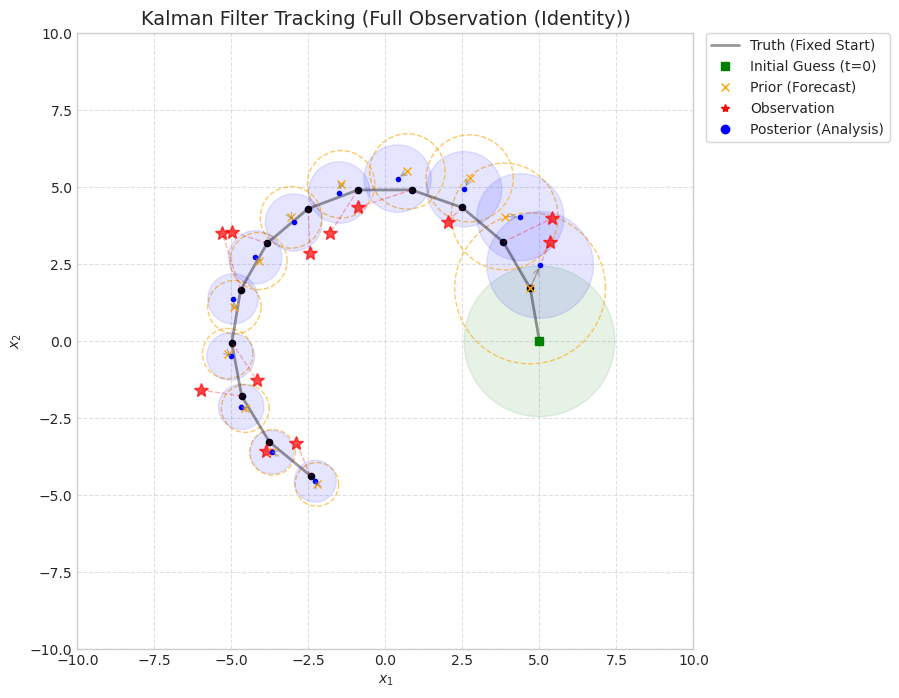

In [3]:
#@title Kalman tracking demo
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.style.use('seaborn-v0_8-whitegrid')

DEFAULT_PARAMETERS = {
    "kalman_tracking": {
        "random_seed": 42,
        "steps": 12,
        "observation_mode": "Full Observation (Identity)",
        "dynamics_noise_std": 0.01,
        "observation_noise_std": 1.0,
        "initial_guess_x": 5.0,
        "initial_guess_y": 0.0,
        "initial_uncertainty": 1.0,
    },
}

use_default = False #@param {type:"boolean"}
observation_mode = "Full Observation (Identity)" #@param ["Full Observation (Identity)", "Partial Observation (Only x)"]
initial_guess_x = 5.0 #@param {type:"slider", min:-8.0, max:8.0, step:0.5}
initial_guess_y = 0.0 #@param {type:"slider", min:-8.0, max:8.0, step:0.5}
initial_uncertainty = 1.0 #@param {type:"slider", min:0.1, max:3.0, step:0.1}
dynamics_noise_std = 0.01 #@param {type:"slider", min:0.001, max:0.05, step:0.001}
observation_noise_std = 1.0 #@param {type:"slider", min:0.1, max:3.0, step:0.1}

params = DEFAULT_PARAMETERS["kalman_tracking"]
if use_default:
    random_seed = params["random_seed"]
    steps = params["steps"]
    observation_mode = params["observation_mode"]
    dynamics_noise_std = params["dynamics_noise_std"]
    observation_noise_std = params["observation_noise_std"]
    initial_guess_x = params["initial_guess_x"]
    initial_guess_y = params["initial_guess_y"]
    initial_uncertainty = params["initial_uncertainty"]
else:
    random_seed = params["random_seed"]
    steps = params["steps"]

OBS_CONFIGS = {
    'Full Observation (Identity)': {'matrix': np.eye(2), 'dim': 2},
    'Partial Observation (Only x)': {'matrix': np.array([[1.0, 0.0]]), 'dim': 1},
}


def get_cov_ellipse(cov, centre, n_std=2.448, **kwargs):
    cov = (cov + cov.T) / 2
    lambda_, v = np.linalg.eigh(cov)
    order = lambda_.argsort()[::-1]
    lambda_ = lambda_[order]
    v = v[:, order]
    angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(lambda_, 0))
    return Ellipse(xy=centre, width=width, height=height, angle=angle, **kwargs)


def kalman_filter_step(m_prior, C_prior, y, H, Gamma):
    S = H @ C_prior @ H.T + Gamma
    K = C_prior @ H.T @ np.linalg.inv(S)
    m_post = m_prior + K @ (y - H @ m_prior)
    C_post = (np.eye(len(m_prior)) - K @ H) @ C_prior
    return m_post, C_post


def generate_data(steps, obs_mode_key, dyn_noise_std, obs_noise_std):
    theta = 0.35
    A = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])

    config = OBS_CONFIGS[obs_mode_key]
    H = config['matrix']
    obs_dim = config['dim']

    Sigma = np.eye(2) * (dyn_noise_std**2)
    Gamma = np.eye(obs_dim) * (obs_noise_std**2)

    np.random.seed(random_seed)
    v_true = np.zeros((steps + 1, 2))
    v_true[0] = [5.0, 0.0]
    ys = []

    for k in range(steps):
        v_true[k + 1] = A @ v_true[k] + np.random.multivariate_normal([0, 0], Sigma)
        noise = np.random.multivariate_normal(np.zeros(obs_dim), Gamma)
        ys.append(H @ v_true[k + 1] + noise)

    return v_true, ys, A, H, Sigma, Gamma


guess_mean = np.array([initial_guess_x, initial_guess_y])
v_true, ys, A, H, Sigma, Gamma = generate_data(
    steps,
    observation_mode,
    dynamics_noise_std,
    observation_noise_std,
)

m_curr = guess_mean
C_curr = np.eye(2) * (initial_uncertainty**2)
priors = []
posts = [(m_curr, C_curr)]

for k in range(steps):
    m_prior = A @ m_curr
    C_prior = A @ C_curr @ A.T + Sigma
    priors.append((m_prior, C_prior))

    m_post, C_post = kalman_filter_step(m_prior, C_prior, ys[k], H, Gamma)
    posts.append((m_post, C_post))
    m_curr, C_curr = m_post, C_post

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(v_true[:, 0], v_true[:, 1], 'k-', alpha=0.4, label='Truth (Fixed Start)', linewidth=2)
ax.scatter(v_true[:, 0], v_true[:, 1], c='k', s=20)

ell_init = get_cov_ellipse(posts[0][1], posts[0][0], edgecolor='green', linestyle='-', facecolor='green', alpha=0.1)
ax.add_patch(ell_init)
ax.plot(posts[0][0][0], posts[0][0][1], 's', color='green', label='Initial Guess (t=0)')

for k in range(steps):
    m_pri, C_pri = priors[k]
    m_pos, C_pos = posts[k + 1]
    y_val = ys[k]
    true_pos = v_true[k + 1]

    if observation_mode == 'Full Observation (Identity)':
        ax.plot(y_val[0], y_val[1], 'r*', markersize=10, alpha=0.7)
        ax.plot([true_pos[0], y_val[0]], [true_pos[1], y_val[1]],
                color='red', linestyle='--', alpha=0.3, linewidth=1)
    else:
        ax.axvline(x=y_val[0], color='red', linestyle='-', alpha=0.3, linewidth=1.5)
        ax.plot([true_pos[0], y_val[0]], [true_pos[1], true_pos[1]],
                color='red', linestyle='--', alpha=0.3, linewidth=1)

    ell_pri = get_cov_ellipse(C_pri, m_pri, edgecolor='orange', linestyle='--', facecolor='none', alpha=0.6)
    ax.add_patch(ell_pri)
    ax.plot(m_pri[0], m_pri[1], 'x', color='orange', markersize=6)

    ell_pos = get_cov_ellipse(C_pos, m_pos, edgecolor='blue', linestyle='-', facecolor='blue', alpha=0.1)
    ax.add_patch(ell_pos)
    ax.plot(m_pos[0], m_pos[1], '.', color='blue', markersize=6)

    ax.annotate("", xy=(m_pos[0], m_pos[1]), xytext=(m_pri[0], m_pri[1]),
                arrowprops=dict(arrowstyle="->", color="gray", alpha=0.5))

ax.plot([], [], 'x', color='orange', label='Prior (Forecast)')
ax.plot([], [], 'r*', label='Observation')
if observation_mode != 'Full Observation (Identity)':
    ax.plot([], [], 'r-', label='Observed Subspace', alpha=0.5)
ax.plot([], [], 'o', color='blue', label='Posterior (Analysis)')

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title(f'Kalman Filter Tracking ({observation_mode})', fontsize=14)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, frameon=True)
ax.grid(True, linestyle='--', alpha=0.6)
fig.subplots_adjust(right=0.76)
plt.show()
